In [1]:
import numpy as np
import matplotlib.pyplot as plt
from langevin_samplers import (run_hmc,run_k_langevin,run_od_langevin, several_runs) 

In [2]:
#anisotropic gaussian potential
def U_anipara(x):
    x1,x2 = x
    return 0.5*x1**2 + 0.5*10*x2**2

def gradU_anipara(x):
    x1,x2 = x
    return np.array([x1, 10*x2])

def empirical_cov(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    return (Xc.T @ Xc) / X.shape[0]


The goal of following cells is to visualize the 'forgetting initial velocity' phenomenon. It can be shown that $Cov(v_0, v_n)$, where $v_n$ is the velocity at step $n$, is a bounded oscillating function, which decreases to 0 in time. 

The goal could be to not only plot the evolution of this quantity throughout the trajectory, but also to plot it in function of the parameter $\gamma = \frac{1 - \eta}{K \delta}$, which is in reality the inverse of the 'half-life' of the covariance.

In [3]:
def covariance_vt_v0(V_ensemble):
    # Initial velocities for each run
    V0 = V_ensemble[:, 0, :]          # shape (n_runs, d)

    # V_ensemble * V0[:, None, :] -> (n_runs, T, d)
    cov = np.mean(V_ensemble * V0[:, None, :], axis=0)

    return cov #shape (N*K, d)

In [5]:
#parameters 
gradU = gradU_anipara
sampler = run_k_langevin
x0 = np.array([1.0,1.0])
v0 = np.random.randn(2)
eta = 0.98
delta = 0.1
K = 1

X_ens, V_ens = several_runs(x0, v0, gradU_anipara,sampler=run_k_langevin,n=20000,N=500,delta=delta,K=K,eta=eta)

cov = covariance_vt_v0(V_ens)




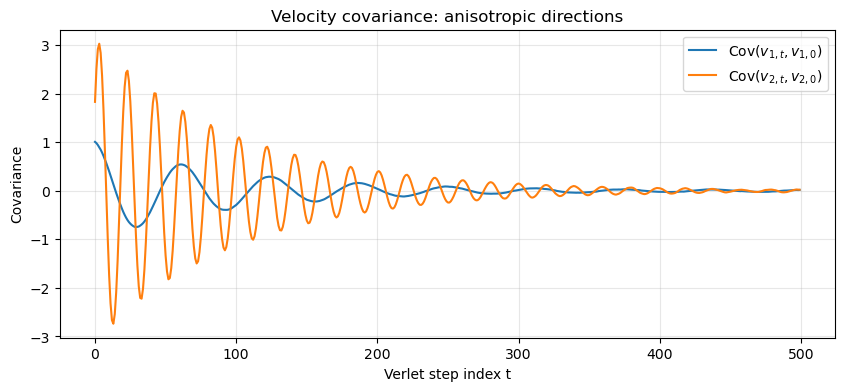

In [11]:
T = cov.shape[0]
t = np.arange(T)

plt.figure(figsize=(10,4))

plt.plot(t, cov[:,0], label=r"$\mathrm{Cov}(v_{1,t},v_{1,0})$")
plt.plot(t, cov[:,1], label=r"$\mathrm{Cov}(v_{2,t},v_{2,0})$")

plt.xlabel("Verlet step index t")
plt.ylabel("Covariance")
plt.title("Velocity covariance: anisotropic directions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<Figure size 1200x400 with 0 Axes>

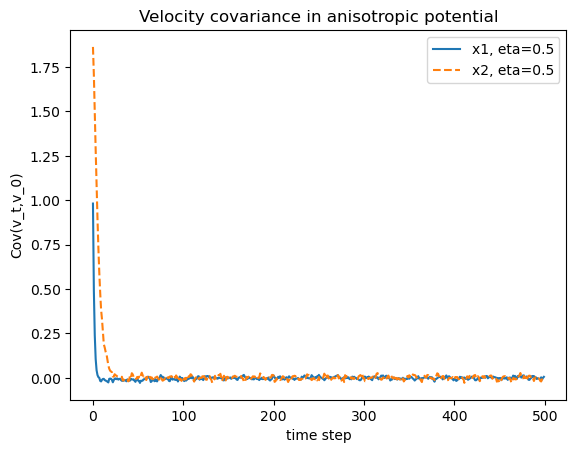

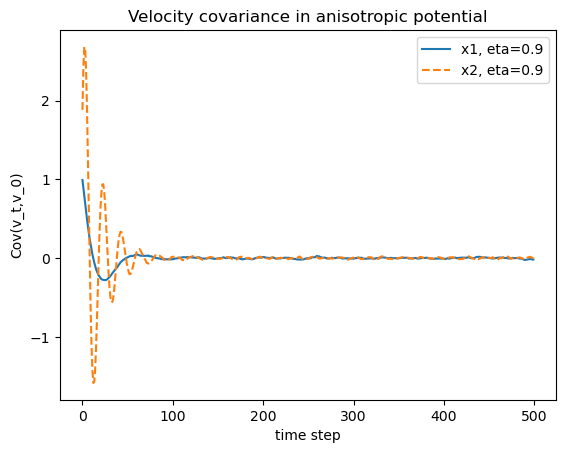

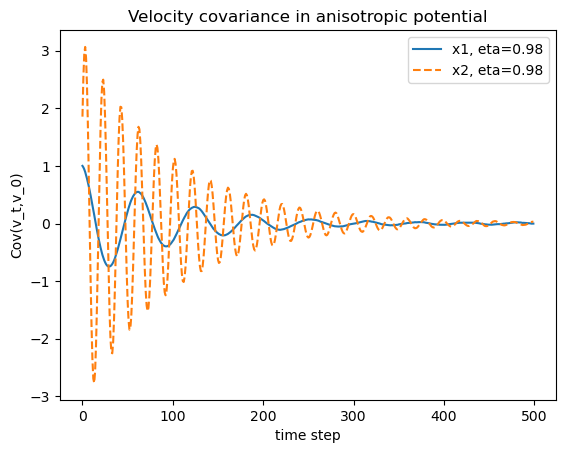

In [14]:
etas = [0.5, 0.9, 0.98]

plt.figure(figsize=(12,4))

for eta in etas:

    X_ens, V_ens = several_runs(
        x0, v0, gradU_anipara,
        sampler=run_k_langevin,
        n=20000, N=500,
        delta=delta, K=K, eta=eta
    )

    cov = covariance_vt_v0(V_ens)

    t = np.arange(cov.shape[0])
    
    plt.figure()
    plt.plot(t, cov[:,0], label=f"x1, eta={eta}")
    plt.plot(t, cov[:,1], "--", label=f"x2, eta={eta}")
    plt.xlabel("time step")
    plt.ylabel("Cov(v_t,v_0)")
    plt.title("Velocity covariance in anisotropic potential")
    plt.legend()
    plt.show()



In [8]:
#function for bounding the oscillations
def theoretical_oscillation_constants(eta, delta):
    """
    Returns phi and C such that
    |Cov(v_t, v_0)| <= C * (sqrt(eta))^t
    """
    c = np.cos(delta)
    rho = np.sqrt(eta)

    cos_phi = (1 + eta) * c / (2 * rho)

    # numerical safety
    cos_phi = np.clip(cos_phi, -1.0, 1.0)
    phi = np.arccos(cos_phi)

    # amplitude coefficient A
    A = (eta * c - rho * cos_phi) / (rho * np.sin(phi))

    # global envelope constant
    C = np.sqrt(1 + A**2)

    return phi, C

def covariance_bounds(T, eta, delta):
    """
    Compute upper and lower theoretical bounds for Cov(v_t, v_0).

    Parameters
    ----------
    T : int
        number of time steps
    eta : float
        refreshment parameter
    delta : float
        Verlet time step (K=1)

    Returns
    -------
    lower, upper : arrays of shape (T,)
        theoretical bounds
    """
    _, C = theoretical_oscillation_constants(eta, delta)
    rho = np.sqrt(eta)

    t = np.arange(T)
    envelope = C * (rho ** t)

    return -envelope, envelope


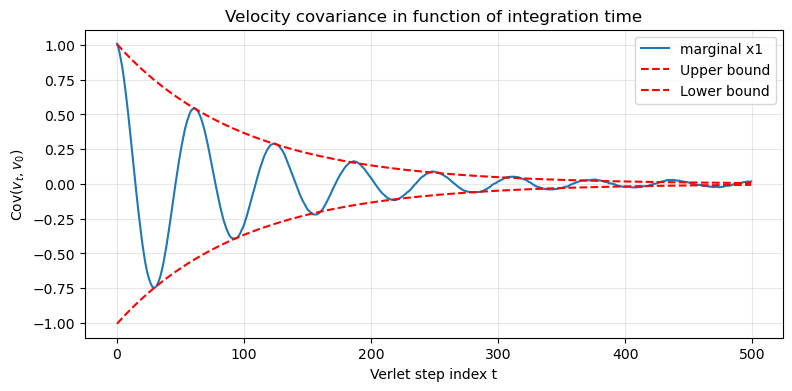

In [10]:
T = cov.shape[0]
t = np.arange(T)
lower, upper = covariance_bounds(T, eta, delta)

plt.figure(figsize=(9, 4))
#plot for marginal one
plt.plot(t, cov[:, 0], label=f"marginal x1")
plt.plot(t, upper, "r--", label="Upper bound")
plt.plot(t, lower, "r--", label="Lower bound")

plt.xlabel("Verlet step index t")
plt.ylabel(r"$\mathrm{Cov}(v_t, v_0)$")
plt.title("Velocity covariance in function of integration time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()